Data loading: Placeholder data used. Ensure to replace with actual finance data.

--- Q1 (Category 5): LDA Model Training and Evaluation (TM A) ---
LDA Model Accuracy: 0.3033
LDA Confusion Matrix:
[[22 50 28]
 [30 46 25]
 [24 52 23]]
LDA Feature Coefficients (First Discriminant, Standardized Data):
  RSI_14: 0.0446
  MACD_Signal: -0.0084
  Vol_Index: -0.0561
  Momentum: -0.0160
  Market_Breadth: -0.0205


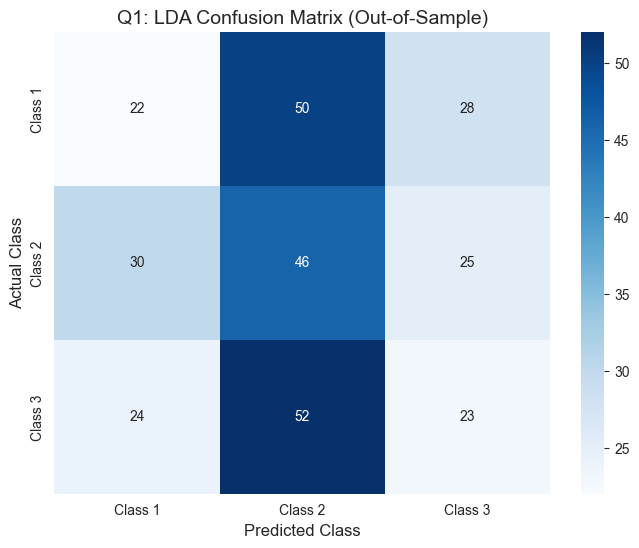


--- Q2 (Category 6): SVM Model Training and Evaluation (TM B) ---
Optimal SVM Hyperparameters: {'C': 1, 'kernel': 'linear'}
Optimal SVM Model Accuracy: 0.3133
Optimal SVM Classification Report (F1-Score, etc.):
              precision    recall  f1-score   support

           1       0.29      0.24      0.26       100
           2       0.32      0.46      0.38       101
           3       0.32      0.24      0.28        99

    accuracy                           0.31       300
   macro avg       0.31      0.31      0.31       300
weighted avg       0.31      0.31      0.31       300



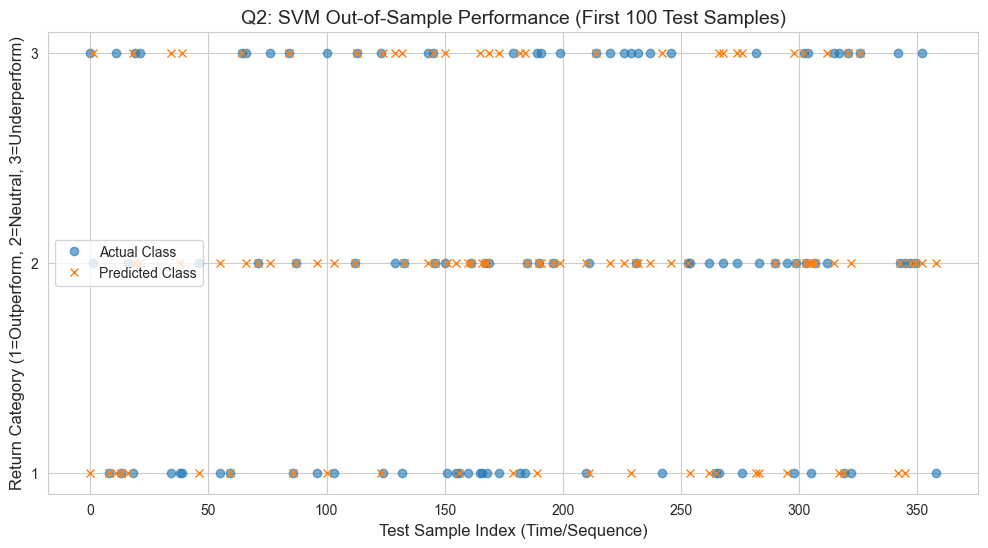


--- Q3 (Category 7): Neural Network Model Training and Evaluation (TM C) ---
FNN Model Test Accuracy: 0.3367
FNN Model Test Loss: 1.1872
10/10 [==============================] - 0s 1ms/step


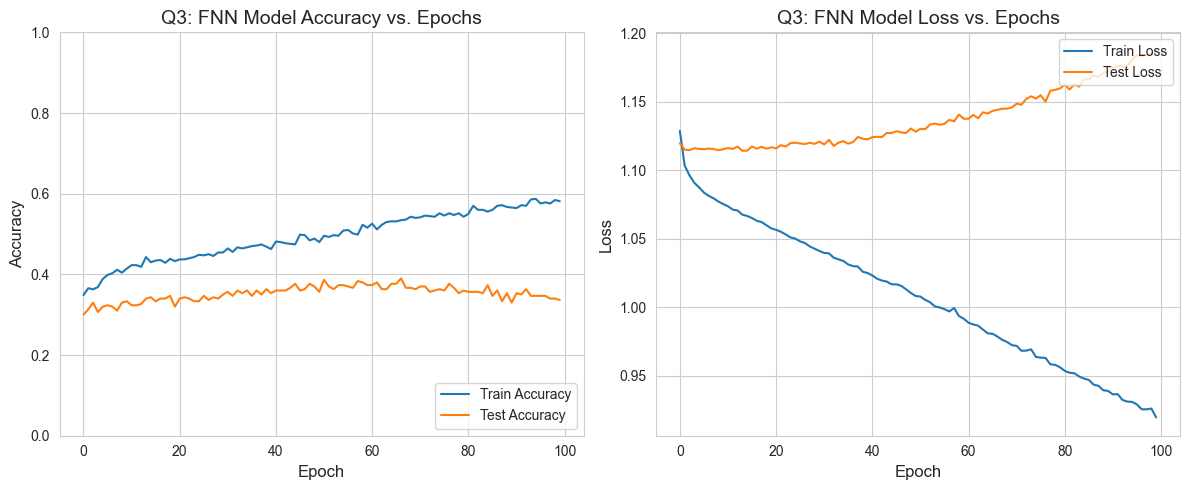

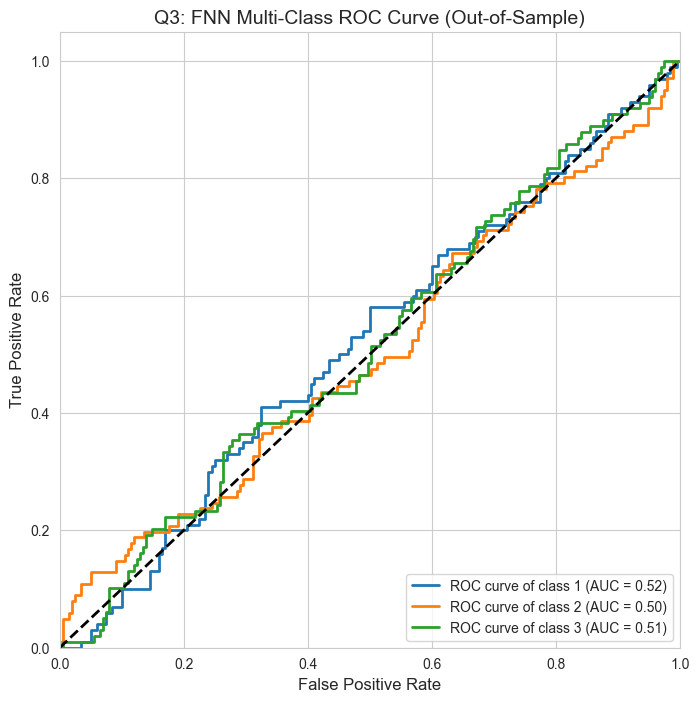


--- All Quantitative Analysis computations complete. ---


In [4]:
# ==============================================================================
# MSCFE 632 Machine Learning in Finance - Group Work Project #2
# Single Executable Jupyter Notebook (Technical Report Computation)
#
# This file contains all computations, marked by Category and responsible Team Member.
# 
# Category 5 (LDA) = Team Member A
# Category 6 (SVM) = Team Member B
# Category 7 (NN)  = Team Member C
# ==============================================================================

# ==============================================================================
# 0. Setup and Data Preparation (Group Task)
# ==============================================================================

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical

# Set plot style for professional-looking graphs
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- Data Loading and Feature Engineering Placeholder ---
# NOTE: Replace this section with your actual data loading and feature engineering.

# Placeholder Data (DELETE THIS BLOCK AND REPLACE WITH YOUR ACTUAL FINANCE DATA)
n_samples = 1000
n_features = 5
feature_names = ['RSI_14', 'MACD_Signal', 'Vol_Index', 'Momentum', 'Market_Breadth']
X = pd.DataFrame(np.random.randn(n_samples, n_features), columns=feature_names)
# Create a dummy target with three classes (1, 2, 3)
y = pd.Series(np.random.randint(1, 4, n_samples)).astype('category') 
y.name = 'Return_Category'
print("Data loading: Placeholder data used. Ensure to replace with actual finance data.")

# --- Data Splitting and Scaling ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)


# ==============================================================================
# 1. Quantitative Analysis - Question 1 
# Category 5: Linear Discriminant Analysis (LDA) - Team Member A
# ==============================================================================

print("\n--- Q1 (Category 5): LDA Model Training and Evaluation (TM A) ---")

# --- Model Training ---
# Team Member A: Implement training and evaluation of LDA
lda_model = LDA(solver='svd') 
lda_model.fit(X_train_scaled, y_train)

# --- Prediction and Evaluation ---
y_pred_lda = lda_model.predict(X_test_scaled)
lda_accuracy = accuracy_score(y_test, y_pred_lda)
lda_cm = confusion_matrix(y_test, y_pred_lda)

# 1) Output performance metrics and feature coefficients
print(f"LDA Model Accuracy: {lda_accuracy:.4f}")
print("LDA Confusion Matrix:")
print(lda_cm)
print("LDA Feature Coefficients (First Discriminant, Standardized Data):")
feature_coeffs = lda_model.coef_[0]
for name, coef in zip(feature_names, feature_coeffs):
    print(f"  {name}: {coef:.4f}")

# 2) Plot Confusion Matrix (Required Graph) 
plt.figure(figsize=(8, 6))
class_names = [f'Class {c}' for c in lda_model.classes_]
sns.heatmap(lda_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Q1: LDA Confusion Matrix (Out-of-Sample)', fontsize=14)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()


# ==============================================================================
# 2. Quantitative Analysis - Question 2 
# Category 6: Support Vector Machines (SVM) - Team Member B
# ==============================================================================

print("\n--- Q2 (Category 6): SVM Model Training and Evaluation (TM B) ---")

# --- Hyperparameter Tuning (GridSearch for C and Kernel) ---
# Team Member B: Implement hyperparameter tuning for SVM
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_

# --- Prediction and Evaluation ---
y_pred_svm = best_svm.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm)

# 1) Output optimal hyperparameters and performance metrics
print(f"Optimal SVM Hyperparameters: {svm_grid.best_params_}")
print(f"Optimal SVM Model Accuracy: {svm_accuracy:.4f}")
print("Optimal SVM Classification Report (F1-Score, etc.):")
print(svm_report)


# 2) Plot Predicted vs Actual Classes (Required Graph) 

results_df_svm = pd.DataFrame({
    'Actual': y_test, 
    'Predicted': y_pred_svm
}).sort_index().head(100) # Show first 100 test samples in time/index order

plt.figure(figsize=(12, 6))
plt.plot(results_df_svm.index, results_df_svm['Actual'].astype(float), marker='o', 
         linestyle='', label='Actual Class', alpha=0.6)
plt.plot(results_df_svm.index, results_df_svm['Predicted'].astype(float), marker='x', 
         linestyle='', label='Predicted Class')
plt.title('Q2: SVM Out-of-Sample Performance (First 100 Test Samples)', fontsize=14)
plt.ylabel('Return Category (1=Outperform, 2=Neutral, 3=Underperform)', fontsize=12)
plt.xlabel('Test Sample Index (Time/Sequence)', fontsize=12)
plt.yticks(y_test.cat.categories.tolist()) 
plt.legend()
plt.show()


# ==============================================================================
# 3. Quantitative Analysis - Question 3 
# Category 7: Neural Networks (NN) - Team Member C
# ==============================================================================

print("\n--- Q3 (Category 7): Neural Network Model Training and Evaluation (TM C) ---")

# --- Data Preparation for NN (One-Hot Encoding) ---
# Team Member C: Data preparation for NN
# FIX: Use .cat.codes to get the 0, 1, 2 integer representation of the classes (1, 2, 3)
y_train_nn = to_categorical(y_train.cat.codes) 
y_test_nn = to_categorical(y_test.cat.codes)
n_classes = y_train_nn.shape[1]

# --- Model Construction (FNN Architecture) ---
def create_model(n_hidden_layers, neurons_per_layer, activation='relu', learning_rate=0.001):
    model = Sequential()
    model.add(Dense(neurons_per_layer, input_dim=X_train_scaled.shape[1], activation=activation))
    
    for _ in range(n_hidden_layers - 1):
        model.add(Dense(neurons_per_layer, activation=activation))
        
    model.add(Dense(n_classes, activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Example Architecture (2 hidden layers, 30 neurons)
nn_model = create_model(n_hidden_layers=2, neurons_per_layer=30, activation='relu', learning_rate=0.001)

# --- Training and History Tracking ---
history = nn_model.fit(X_train_scaled, y_train_nn, epochs=100, batch_size=32, 
                       validation_data=(X_test_scaled, y_test_nn), verbose=0)

# --- Prediction and Evaluation ---
loss, accuracy = nn_model.evaluate(X_test_scaled, y_test_nn, verbose=0)
print(f"FNN Model Test Accuracy: {accuracy:.4f}")
print(f"FNN Model Test Loss: {loss:.4f}")

# Get predicted probabilities for ROC curve
y_pred_proba_nn = nn_model.predict(X_test_scaled)


# 2) Plot Loss/Accuracy vs Epochs (Required Graph) 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Q3: FNN Model Accuracy vs. Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='lower right')
plt.ylim([0, 1])

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Q3: FNN Model Loss vs. Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


# 3) Plot Multi-Class ROC Curve (Required Graph) 

plt.figure(figsize=(8, 8))
lw = 2
class_labels = y_test.cat.categories.tolist()

for i in range(n_classes):
    # Calculate ROC curve for each class (One-vs-Rest)
    fpr, tpr, _ = roc_curve(y_test_nn[:, i], y_pred_proba_nn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=lw, 
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Q3: FNN Multi-Class ROC Curve (Out-of-Sample)', fontsize=14)
plt.legend(loc="lower right")
plt.show()

print("\n--- All Quantitative Analysis computations complete. ---")
# END OF JUPYTER NOTEBOOK FILE